# CBIS-DDSM Dataset Exploration

1. Dataset index and label distributions
2. Raw mammograms with mass masks — diverse sample selection
3. Spatial preprocessing: raw → oriented · cropped · denoised with masks
4. Step-by-step pipeline walkthrough (MLO)
5. Colour representations on preprocessed images

In [47]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import cv2
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

from dataset import build_sample_index
from preprocess import (
    apply_clahe, make_clahe_triple, make_pseudo_color,
    orient_breast, remove_pectoral_muscle, tight_crop_breast, denoise,
    _otsu_breast_mask, _largest_connected_component,
    MammogramPreprocessor,
)
from config import PreprocessConfig, Representation

%matplotlib inline

mpl.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size":         9,
    "axes.titlesize":    9,
    "axes.titlepad":     5,
    "axes.labelsize":    8,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

GOLD   = np.array([1.0, 0.84, 0.0])
GOLD_C = (255, 215, 0)
COLORS = {"BENIGN": "#4878CF", "MALIGNANT": "#D65F5F", "UNKNOWN": "#888888"}
DENSITY_LABEL = {1: "A (fatty)", 2: "B (scattered)",
                 3: "C (heterogeneous)", 4: "D (dense)"}


# ── Display helpers ───────────────────────────────────────────────────────────

def stretch(img: np.ndarray, lo: float = 1.0, hi: float = 99.0) -> np.ndarray:
    img = img.astype(np.float32)
    if img.ndim == 2:
        plo, phi = np.percentile(img, [lo, hi])
        return np.clip((img - plo) / max(phi - plo, 1e-6), 0, 1)
    out = np.empty_like(img)
    for c in range(img.shape[2]):
        plo, phi = np.percentile(img[:, :, c], [lo, hi])
        out[:, :, c] = np.clip((img[:, :, c] - plo) / max(phi - plo, 1e-6), 0, 1)
    return out


def to_rgb_f32(gray: np.ndarray) -> np.ndarray:
    norm = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return cv2.cvtColor(norm, cv2.COLOR_GRAY2RGB).astype(np.float32) / 255.0


def apply_overlay(rgb_f32: np.ndarray, mask: np.ndarray, alpha: float = 0.35) -> np.ndarray:
    """Return uint8 RGB with gold fill + contour over mask region."""
    overlay = rgb_f32.copy()
    m = mask > 127
    overlay[m] = (1 - alpha) * overlay[m] + alpha * GOLD
    out = (np.clip(overlay, 0, 1) * 255).astype(np.uint8)
    contours, _ = cv2.findContours(m.astype(np.uint8),
                                    cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(out, contours, -1, GOLD_C, 2)
    return out


def show_img(ax, img, cmap="gray", vmin=None, vmax=None):
    """Show image preserving true aspect ratio (no squashing)."""
    if img.ndim == 3:
        ax.imshow(img)
    else:
        v0 = vmin if vmin is not None else np.percentile(img, 1)
        v1 = vmax if vmax is not None else np.percentile(img, 99)
        ax.imshow(img, cmap=cmap, vmin=v0, vmax=v1)
    ax.axis("off")


def add_hist(ax, data: np.ndarray, color="#4878CF", xlim=(0,1)):
    ax.hist(data.ravel(), bins=128, range=xlim, color=color, linewidth=0, density=True)
    ax.set_xlim(*xlim)
    ax.set_yticks([])
    ax.set_xlabel("Intensity", fontsize=7)
    ax.spines[["left","top","right"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=6)


# ── Spatial preprocessing helper ──────────────────────────────────────────────

def run_spatial(gray: np.ndarray, view: str):
    """
    Run orient → pectoral removal → tight crop → denoise.
    Returns (preprocessed_gray, flipped, crop_bbox, breast_mask_on_raw).
    """
    if gray.dtype != np.uint8:
        gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    bm = _largest_connected_component(_otsu_breast_mask(gray))
    img, bm, flipped = orient_breast(gray, bm)
    if view.upper() == "MLO":
        img = remove_pectoral_muscle(img, bm)
    img, bbox = tight_crop_breast(img, bm)
    img = denoise(img, 3)
    return img, flipped, bbox, bm


def transform_mask_spatial(mask_bin: np.ndarray, flipped: bool, bbox) -> np.ndarray:
    m = (np.fliplr(mask_bin) if flipped else mask_bin).copy()
    y1, x1, y2, x2 = bbox
    return m[y1:y2, x1:x2]


# ── Sample selection ──────────────────────────────────────────────────────────

def pick_one_per_group(pool, key_fn):
    seen, out = set(), []
    for s in pool:
        k = key_fn(s)
        if k not in seen:
            seen.add(k)
            out.append(s)
    return out


## 1. Load Dataset

In [48]:
DATA_ROOT = os.path.join(PROJECT_ROOT, "data", "cbis-ddsm")
TRAIN_CSV = os.path.join(PROJECT_ROOT, "meta", "cbis-ddsm", "mass_case_description_train_set.csv")
TEST_CSV  = os.path.join(PROJECT_ROOT, "meta", "cbis-ddsm", "mass_case_description_test_set.csv")

train_samples = build_sample_index(os.path.join(DATA_ROOT, "train"), TRAIN_CSV)
test_samples  = build_sample_index(os.path.join(DATA_ROOT, "test"),  TEST_CSV)

candidates     = [s for s in train_samples if s["masks"]]
mlo_candidates = [s for s in candidates if s["view"] == "MLO"]

print(f"Train: {len(train_samples)}  |  Test: {len(test_samples)}")
print(f"Candidates (have masks): {len(candidates)}  |  MLO: {len(mlo_candidates)}")


Train: 1166  |  Test: 348
Candidates (have masks): 1166  |  MLO: 625


In [49]:
rows = []
for split, samples in [("train", train_samples), ("test", test_samples)]:
    for s in samples:
        for m in s["masks"]:
            rows.append({
                "split": split, "patient_id": s["patient_id"],
                "side": s["side"], "view": s["view"], "density": s["density"],
                "pathology": m["pathology"], "assessment": m["assessment"],
                "image_path": s["image_path"], "mask_path": m["path"],
            })
df = pd.DataFrame(rows)
print(f"Total mass annotations: {len(df)}")
df.head(6)


Total mass annotations: 1618


,split,patient_id,side,view,density,pathology,assessment,image_path,mask_path
0,train,P_00001,LEFT,CC,3,MALIGNANT,4,/Users/agotabenjoe/Egyetem/Msc/3 felev/hadamla...,/Users/agotabenjoe/Egyetem/Msc/3 felev/hadamla...
1,train,P_00001,LEFT,MLO,3,MALIGNANT,4,/Users/agotabenjoe/Egyetem/Msc/3 felev/hadamla...,/Users/agotabenjoe/Egyetem/Msc/3 felev/hadamla...
2,train,P_00004,LEFT,CC,3,BENIGN,4,/Users/agotabenjoe/Egyetem/Msc/3 felev/hadamla...,/Users/agotabenjoe/Egyetem/Msc/3 felev/hadamla...
3,train,P_00004,LEFT,MLO,3,BENIGN,4,/Users/agotabenjoe/Egyetem/Msc/3 felev/hadamla...,/Users/agotabenjoe/Egyetem/Msc/3 felev/hadamla...
4,train,P_00004,RIGHT,MLO,3,BENIGN,4,/Users/agotabenjoe/Egyetem/Msc/3 felev/hadamla...,/Users/agotabenjoe/Egyetem/Msc/3 felev/hadamla...
5,train,P_00009,RIGHT,CC,3,MALIGNANT,4,/Users/agotabenjoe/Egyetem/Msc/3 felev/hadamla...,/Users/agotabenjoe/Egyetem/Msc/3 felev/hadamla...


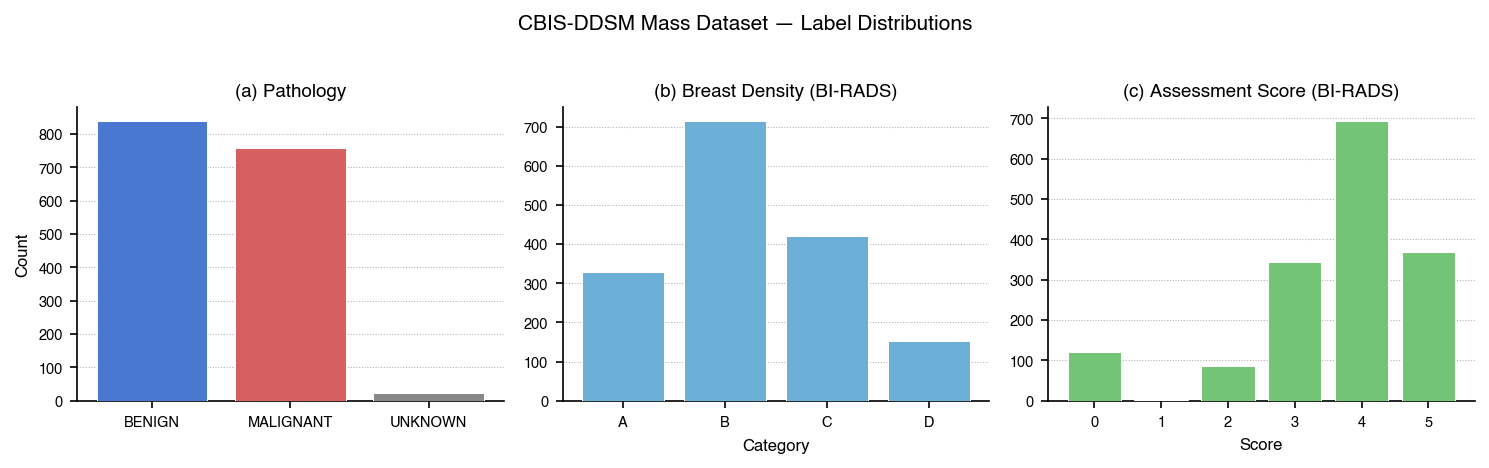

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

counts = df["pathology"].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[COLORS.get(k,"#888") for k in counts.index],
            edgecolor="white", linewidth=0.5, zorder=3)
axes[0].set_title("(a) Pathology"); axes[0].set_ylabel("Count")
axes[0].yaxis.grid(True, linestyle=":", linewidth=0.5, zorder=0)

DLABEL = {1:"A",2:"B",3:"C",4:"D"}
dcounts = df["density"].value_counts().sort_index()
axes[1].bar([DLABEL.get(d,str(d)) for d in dcounts.index], dcounts.values,
            color="#6BAED6", edgecolor="white", linewidth=0.5, zorder=3)
axes[1].set_title("(b) Breast Density (BI-RADS)"); axes[1].set_xlabel("Category")
axes[1].yaxis.grid(True, linestyle=":", linewidth=0.5, zorder=0)

acounts = df["assessment"].value_counts().sort_index()
axes[2].bar(acounts.index.astype(str), acounts.values,
            color="#74C476", edgecolor="white", linewidth=0.5, zorder=3)
axes[2].set_title("(c) Assessment Score (BI-RADS)"); axes[2].set_xlabel("Score")
axes[2].yaxis.grid(True, linestyle=":", linewidth=0.5, zorder=0)

fig.suptitle("CBIS-DDSM Mass Dataset — Label Distributions",
             fontsize=10, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_distributions.pdf", bbox_inches="tight")
plt.show()


## 2. Raw Images with Mass Masks

One sample per pathology × density × view group.

Diverse samples: 23


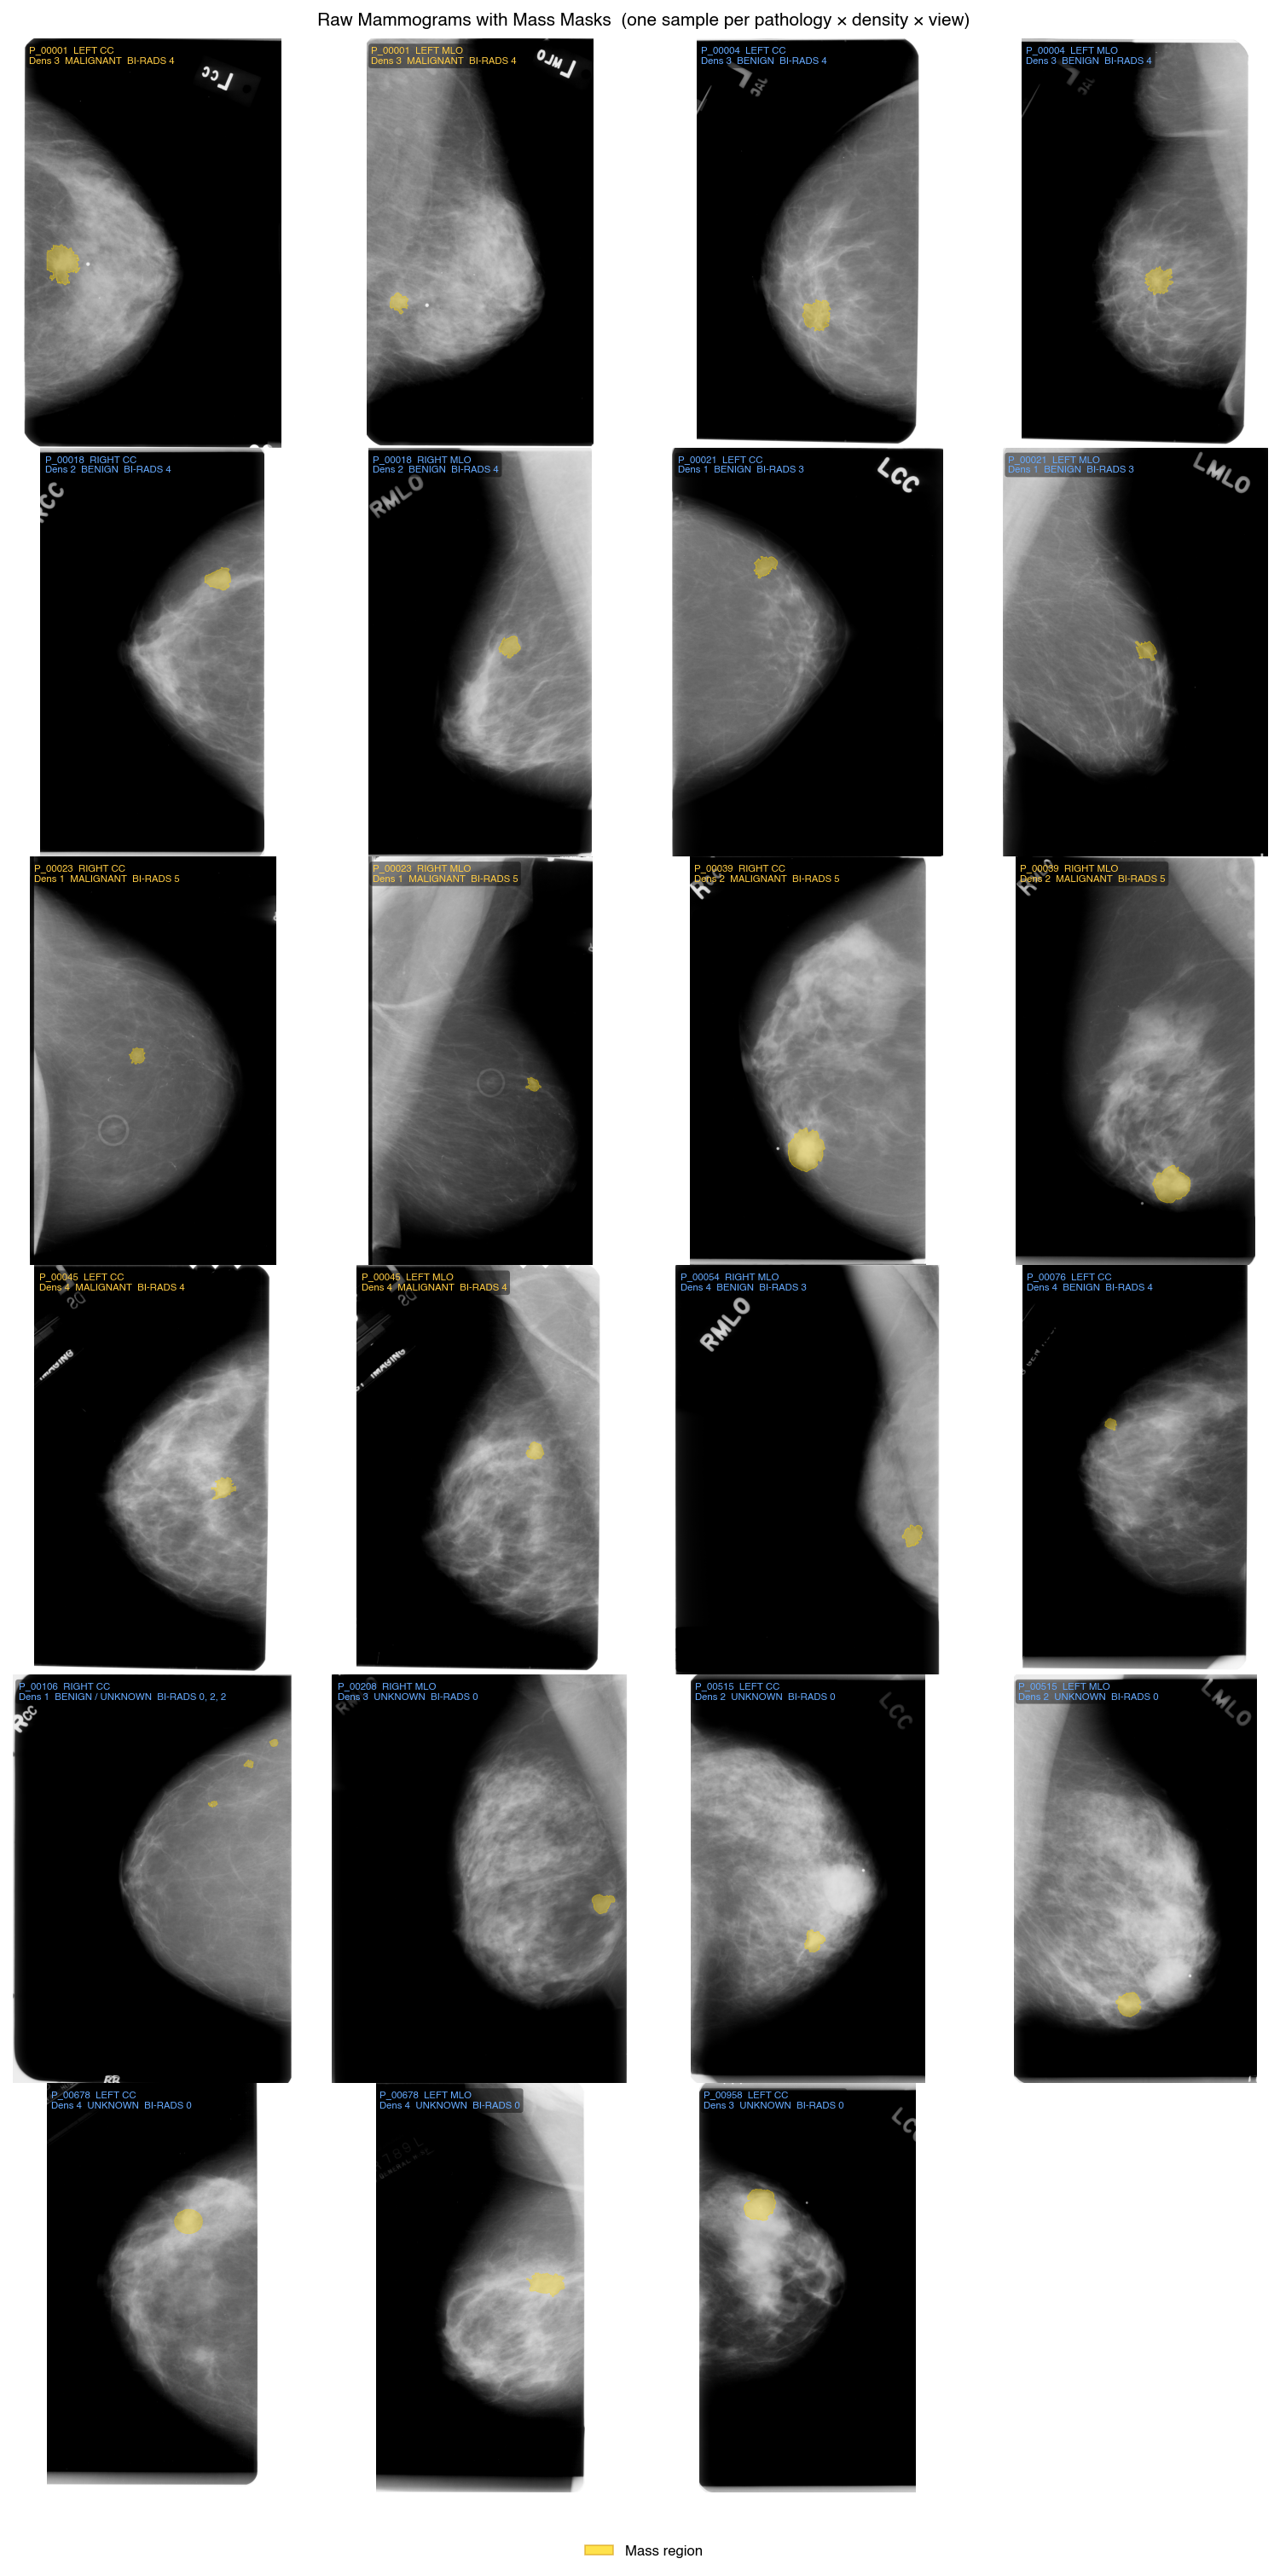

In [51]:
# One sample per (pathology × density × view) group
diverse = pick_one_per_group(
    candidates,
    key_fn=lambda s: (s["masks"][0]["pathology"], s["density"], s["view"])
)
print(f"Diverse samples: {len(diverse)}")

N_COLS = 4
N_ROWS = (len(diverse) + N_COLS - 1) // N_COLS

fig, axes = plt.subplots(N_ROWS, N_COLS,
                          figsize=(N_COLS * 2.6, N_ROWS * 3.4),
                          gridspec_kw={"hspace": 0.0, "wspace": 0.02})
flat = axes.flatten()

for ax, s in zip(flat, diverse):
    gray = cv2.imread(s["image_path"], cv2.IMREAD_GRAYSCALE)
    combined = np.zeros_like(gray)
    for m in s["masks"]:
        raw_m = cv2.imread(m["path"], cv2.IMREAD_GRAYSCALE)
        if raw_m is not None:
            combined = np.maximum(combined, raw_m)

    out = apply_overlay(to_rgb_f32(gray), combined)
    show_img(ax, out)

    path_str = " / ".join(sorted({m["pathology"] for m in s["masks"]}))
    birads   = ", ".join(str(m["assessment"]) for m in s["masks"])
    color    = "#ffcc44" if "MALIGNANT" in path_str else "#66aaff"
    label    = (f"{s['patient_id']}  {s['side']} {s['view']}\n"
                f"Dens {s['density']}  {path_str}  BI-RADS {birads}")

    # Text inside the image — no external title, no inter-row gap
    ax.text(0.02, 0.98, label,
            transform=ax.transAxes, fontsize=5.5, color=color,
            va="top", ha="left",
            bbox=dict(facecolor="black", alpha=0.45, pad=1.5,
                      edgecolor="none", boxstyle="round,pad=0.3"))
    ax.axis("off")

for ax in flat[len(diverse):]:
    ax.set_visible(False)

gold_patch = mpatches.Patch(facecolor="gold", edgecolor="goldenrod",
                             linewidth=0.8, label="Mass region", alpha=0.7)
fig.legend(handles=[gold_patch], loc="lower center", frameon=False,
           fontsize=8, bbox_to_anchor=(0.5, 0.0))
fig.suptitle(
    "Raw Mammograms with Mass Masks  (one sample per pathology × density × view)",
    fontsize=10, fontweight="bold",
)
plt.subplots_adjust(top=0.97, bottom=0.03, left=0.01, right=0.99,
                    hspace=0.0, wspace=0.02)
plt.savefig("fig_raw_masks.pdf", bbox_inches="tight")
plt.show()


## 3. Spatial Preprocessing: Raw → Oriented · Cropped · Denoised

The same mask is spatially transformed alongside the image (flipped, then cropped to the same bounding box).

In [ ]:
# Show raw+mask  →  spatially preprocessed+mask for each diverse sample.
# Layout: N_SAMPLES columns × 2 rows  (raw on top, preprocessed below)

samples_spatial = diverse[:8]   # limit to 8 per figure for readability
N = len(samples_spatial)

fig, axes = plt.subplots(2, N, figsize=(N * 3.2, 9),
                          gridspec_kw={"hspace": 0.08, "wspace": 0.04})

for col, s in enumerate(samples_spatial):
    gray     = cv2.imread(s["image_path"], cv2.IMREAD_GRAYSCALE)
    raw_mask = cv2.imread(s["masks"][0]["path"], cv2.IMREAD_GRAYSCALE)
    raw_bin  = (raw_mask > 127).astype(np.uint8) * 255

    # Spatial preprocessing
    prep, flipped, bbox, _ = run_spatial(gray, s["view"])
    t_mask = transform_mask_spatial(raw_bin, flipped, bbox)

    # Row 0: raw + mask
    show_img(axes[0, col], apply_overlay(to_rgb_f32(gray), raw_bin))
    # Row 1: preprocessed + transformed mask
    show_img(axes[1, col], apply_overlay(to_rgb_f32(prep), t_mask))

    path_str = " / ".join(sorted({m["pathology"] for m in s["masks"]}))
    color    = "#D65F5F" if "MALIGNANT" in path_str else "#4878CF"
    axes[0, col].set_title(
        f"{s['patient_id']}\n{s['side']} {s['view']}  d={s['density']}",
        fontsize=7, color=color, pad=3,
    )
    axes[1, col].set_title(
        f"flipped={flipped}",
        fontsize=6.5, color="#555", pad=2,
    )

# Row labels
for row, label in enumerate(["Raw + mask", "Oriented · Cropped · Denoised + mask"]):
    axes[row, 0].set_ylabel(label, fontsize=8, labelpad=6)
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    axes[row, 0].spines[["top","right","bottom","left"]].set_visible(False)

gold_patch = mpatches.Patch(facecolor="gold", edgecolor="goldenrod",
                             linewidth=0.8, label="Transformed mask", alpha=0.7)
fig.legend(handles=[gold_patch], loc="lower center", frameon=False,
           fontsize=8, bbox_to_anchor=(0.5, -0.005))
fig.suptitle("Spatial Preprocessing: Raw  →  Oriented · Cropped · Denoised",
             fontsize=11, fontweight="bold")
plt.savefig("fig_spatial_preproc.pdf", bbox_inches="tight")
plt.show()


## 4. Step-by-Step Pipeline (MLO view)

Each processing stage shown individually with its pixel intensity histogram.

In [ ]:
s_step = mlo_candidates[0]
raw_st = cv2.imread(s_step["image_path"], cv2.IMREAD_GRAYSCALE)
if raw_st.dtype != np.uint8:
    raw_st = cv2.normalize(raw_st, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

raw_mask_st  = cv2.imread(s_step["masks"][0]["path"], cv2.IMREAD_GRAYSCALE)
raw_bin_st   = (raw_mask_st > 127).astype(np.uint8) * 255

bm_st = _largest_connected_component(_otsu_breast_mask(raw_st))
st_or,  bm_or, flipped_st = orient_breast(raw_st, bm_st)
st_nop = remove_pectoral_muscle(st_or, bm_or)
st_crop, bbox_st = tight_crop_breast(st_nop, bm_or)
st_den = denoise(st_crop, 3)
st_cl  = apply_clahe(st_den, 2.0, 8)

m_or   = (np.fliplr(raw_bin_st) if flipped_st else raw_bin_st).copy()
y1,x1,y2,x2 = bbox_st
m_crop = m_or[y1:y2, x1:x2]

# Build breast-mask contour overlay for first panel
raw_bm_vis = cv2.cvtColor(
    cv2.normalize(raw_st, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8),
    cv2.COLOR_GRAY2RGB,
)
cts, _ = cv2.findContours(bm_st, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(raw_bm_vis, cts, -1, (0, 200, 255), 3)

stages = [
    (raw_bm_vis,  True,  None,    "(a) Raw + breast mask"),
    (st_or,       False, None,    "(b) Oriented"),
    (st_nop,      False, None,    "(c) Pectoral removed"),
    (st_crop,     False, None,    "(d) Tight crop"),
    (st_den,      False, None,    "(e) Denoised"),
    (st_cl,       False, m_crop,  "(f) CLAHE + mask"),
]

fig = plt.figure(figsize=(17, 5.5))
gs  = gridspec.GridSpec(2, len(stages), figure=fig,
                         height_ratios=[3, 1], hspace=0.06, wspace=0.05)

for col, (im, is_rgb, mask_ov, title) in enumerate(stages):
    ax_img  = fig.add_subplot(gs[0, col])
    ax_hist = fig.add_subplot(gs[1, col])

    if is_rgb:
        ax_img.imshow(im)
    elif mask_ov is not None:
        ax_img.imshow(apply_overlay(to_rgb_f32(im), mask_ov))
    else:
        ax_img.imshow(im, cmap="gray",
                      vmin=np.percentile(im,1), vmax=np.percentile(im,99))
    ax_img.axis("off")
    ax_img.set_title(title, fontsize=8, pad=3)

    data = im if is_rgb else im
    add_hist(ax_hist, stretch(
        data.mean(axis=2) if data.ndim == 3 else data.astype(np.float32)
    ))

fig.suptitle(
    f"Step-by-Step Pipeline  —  "
    f"{s_step['patient_id']} {s_step['side']} {s_step['view']}  "
    f"({s_step['masks'][0]['pathology']})",
    fontsize=10, fontweight="bold", y=1.01,
)
plt.savefig("fig_pipeline_steps.pdf", bbox_inches="tight")
plt.show()


## 5. Colour Representations on Preprocessed Images

Pseudo-Color (top row) and CLAHE-Triple (bottom row) applied to the fully spatially preprocessed image. All channels are per-channel stretched for display. Gold contour = transformed mass mask.

In [ ]:
# For each diverse sample: show CLAHE · CLAHE-Triple · Pseudo-Color
# all applied to the PREPROCESSED base (spatially cleaned image).
# Layout per sample: 2 rows × 4 cols
#   Row 0 (Pseudo-Color): ch0 CLAHE | ch1 Top-hat | ch2 Black-hat | RGB composite + mask
#   Row 1 (CLAHE-Triple): ch0 c=1   | ch1 c=2     | ch2 c=3       | composite + mask

cfg_pc = PreprocessConfig(representation=Representation.PSEUDO_COLOR,  target_size=(512,400))
cfg_ct = PreprocessConfig(representation=Representation.CLAHE_TRIPLE,   target_size=(512,400))
pre_pc = MammogramPreprocessor(cfg_pc)
pre_ct = MammogramPreprocessor(cfg_ct)

for s in diverse[:8]:
    gray     = cv2.imread(s["image_path"],         cv2.IMREAD_GRAYSCALE)
    raw_mask = cv2.imread(s["masks"][0]["path"],   cv2.IMREAD_GRAYSCALE)
    raw_bin  = (raw_mask > 127).astype(np.uint8) * 255

    pc_img, tx_pc = pre_pc(gray, view=s["view"])
    ct_img, tx_ct = pre_ct(gray, view=s["view"])

    mask_pc = pre_pc.transform_mask(raw_bin, tx_pc)
    mask_ct = pre_ct.transform_mask(raw_bin, tx_ct)

    pc_d = stretch(pc_img)
    ct_d = stretch(ct_img)

    fig, axes = plt.subplots(2, 4, figsize=(14, 6.5),
                              gridspec_kw={"hspace": 0.08, "wspace": 0.04})

    # Row 0 — Pseudo-Color
    pc_info = [
        ("(a) ch0  CLAHE gray",    pc_d[:,:,0], "gray"),
        ("(b) ch1  Top-hat",       pc_d[:,:,1], "hot"),
        ("(c) ch2  Black-hat",     pc_d[:,:,2], "bone"),
        ("(d) RGB composite + mask", None,     None),
    ]
    for i, (title, im, cmap) in enumerate(pc_info):
        ax = axes[0, i]
        if im is not None:
            ax.imshow(im, cmap=cmap, vmin=0, vmax=1)
        else:
            ax.imshow(apply_overlay(pc_d.copy(), mask_pc))
        ax.axis("off")
        ax.set_title(title, fontsize=8)

    # Row 1 — CLAHE-Triple
    ct_info = [
        ("(e) ch0  clip = 1",      ct_d[:,:,0], "gray"),
        ("(f) ch1  clip = 2",      ct_d[:,:,1], "gray"),
        ("(g) ch2  clip = 3",      ct_d[:,:,2], "gray"),
        ("(h) RGB composite + mask", None,     None),
    ]
    for i, (title, im, cmap) in enumerate(ct_info):
        ax = axes[1, i]
        if im is not None:
            ax.imshow(im, cmap=cmap, vmin=0, vmax=1)
        else:
            ax.imshow(apply_overlay(ct_d.copy(), mask_ct))
        ax.axis("off")
        ax.set_title(title, fontsize=8)

    # Row labels
    for row, lbl in enumerate(["Pseudo-Color", "CLAHE-Triple"]):
        axes[row, 0].set_ylabel(lbl, fontsize=9, fontweight="bold", labelpad=6)
        axes[row, 0].axis("on")
        axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
        axes[row, 0].spines[["top","right","bottom","left"]].set_visible(False)

    path_str = s["masks"][0]["pathology"]
    birads   = s["masks"][0]["assessment"]
    color    = "#D65F5F" if path_str == "MALIGNANT" else "#4878CF"
    dens_str = DENSITY_LABEL.get(s["density"], str(s["density"]))

    fig.suptitle(
        f"{s['patient_id']}  {s['side']} {s['view']}  ·  "
        f"Density {s['density']} ({dens_str})  ·  {path_str}  ·  BI-RADS {birads}",
        fontsize=10, fontweight="bold", color=color,
    )
    fname = f"fig_colors_{s['patient_id']}_{s['side']}_{s['view']}.pdf"
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
